In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import joblib

# Load processed (model) data
model_df = pd.read_csv("../data/processed/model_data.csv")

model_df.head()

,StockCode,Month,UnitsSold,AvgPrice,Revenue,lag_1_units,rolling_3_units,price_change_pct,month_num,year
0,15036,2011-02-01,2172,0.740476,1449.00,912.0,1072.000000,0.012040,2,2011
1,15036,2011-03-01,2912,0.735000,1986.00,2172.0,1998.666667,-0.007395,3,2011
2,15036,2011-04-01,1900,0.813667,1431.68,2912.0,2328.000000,0.107029,4,2011
3,15036,2011-05-01,3888,0.820000,2921.04,1900.0,2900.000000,0.007784,5,2011
4,15036,2011-06-01,3096,0.819800,2323.08,3888.0,2961.333333,-0.000244,6,2011


In [2]:
model_df = pd.get_dummies(model_df, columns=['StockCode'])

In [3]:
# Select features and target
features = [col for col in model_df.columns if col not in ['UnitsSold', 'Month']]

target = 'UnitsSold'

In [4]:
model_df.head()

,Month,UnitsSold,AvgPrice,Revenue,lag_1_units,rolling_3_units,price_change_pct,month_num,year,StockCode_15036,...,StockCode_84755,StockCode_84879,StockCode_84946,StockCode_84978,StockCode_84991,StockCode_84992,StockCode_85099B,StockCode_85099C,StockCode_85099F,StockCode_85123A
0,2011-02-01,2172,0.740476,1449.00,912.0,1072.000000,0.012040,2,2011,1,...,0,0,0,0,0,0,0,0,0,0
1,2011-03-01,2912,0.735000,1986.00,2172.0,1998.666667,-0.007395,3,2011,1,...,0,0,0,0,0,0,0,0,0,0
2,2011-04-01,1900,0.813667,1431.68,2912.0,2328.000000,0.107029,4,2011,1,...,0,0,0,0,0,0,0,0,0,0
3,2011-05-01,3888,0.820000,2921.04,1900.0,2900.000000,0.007784,5,2011,1,...,0,0,0,0,0,0,0,0,0,0
4,2011-06-01,3096,0.819800,2323.08,3888.0,2961.333333,-0.000244,6,2011,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Train/Test split
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [6]:
# Train model (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [7]:
# Evaluate
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 367.732380952381
R2: 0.7332171169990678


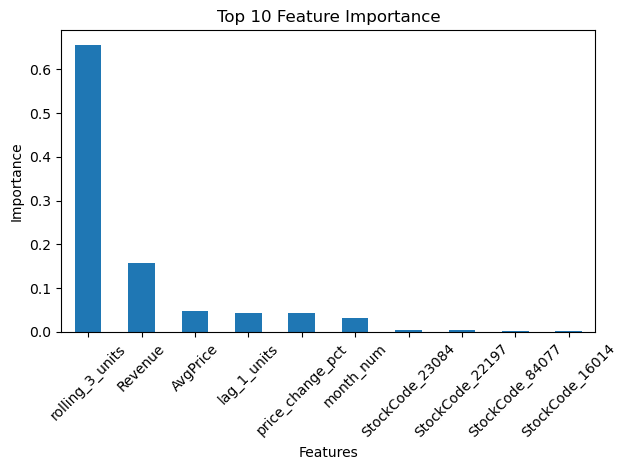

In [8]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=features)

# Sort
importance = importance.sort_values(ascending=False)

# Keep top 10
top_features = importance.head(10)

# Plot
top_features.plot(kind='bar')

plt.title("Top 10 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/top_10_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print("Linear R2:", r2_score(y_test, lr_preds))

Linear R2: 0.5992979901906227


In [10]:
# Save model
joblib.dump(model, "../models/demand_model.pkl")

['../models/demand_model.pkl']